1
a
Load the Breast cancer Wisconsin (diagnostic) dataset.
i) Explore the dataset by printing the first 5 rows including feature names and the target variable.
ii)Perform exploratory data analysis (EDA) by checking the dataset's shape, summary statistics, and missing values
iii) Split the dataset into training (80%) and testing (20%) sets.
b
Train an SVM model with a radial basis function (RBF) kernel on the training set. Set the C parameter to 1.0, and use the default settings for other parameters. Show the confusion matrix and calculate the accuracy of the test set.
c
Train a KNN model with k=5 on the same training set. Show the confusion matrix and calculate the accuracy of the test set.
NB: Don't use the inbuilt function for KNN in sklearn
d
Compare the accuracy in each case. Plot the ROC curve for each classifier

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc

In [9]:
# 1.a
data = load_breast_cancer()

#i
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target']=data.target
print(df.head())

#ii
print("Shape: ",df.shape)
print("Statistics: ", df.describe())
print("Missing values: ",df.isnull().sum())

#iii
X=data.data
y=data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [27]:
#1.b

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

svm = SVC(kernel='rbf', C = 0.1, probability = True)
svm.fit(X_train, y_train)

y_pred_s = svm.predict(X_test)

print("Confusion Matrix: \n", confusion_matrix(y_test,y_pred))
print("Accuracy : ", accuracy_score(y_test,y_pred))

Confusion Matrix: 
 [[ 59   4]
 [  3 105]]
Accuracy :  0.9590643274853801


In [25]:
#1.c
from collections import Counter

def eculidDist(x1, x2):
  return np.sqrt(np.sum((x1-x2)**2))

def knn(X_train, y_train, X_test, k=5):
  predictions = []
  for test_point in X_test:
    distance = []
    for i in range(len(X_train)):
      dist = eculidDist(test_point, X_train[i])
      distance.append((dist, y_train[i]))
    distance.sort(key = lambda x:x[0])
    k_neighbors = distance[:k]
    labels = [label for _, label in k_neighbors]
    mostComm = Counter(labels).most_common(1)[0][0]
    predictions.append(mostComm)
  return np.array(predictions)

y_pred_k = knn(X_train, y_train, X_test, k=5)
print("confusionMatrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy : ", np.mean(y_pred==y_test))

confusionMatrix:
 [[ 59   4]
 [  3 105]]
Accuracy :  0.9590643274853801


SVM Accuracy: 0.935672514619883
KNN Accuracy: 0.9590643274853801


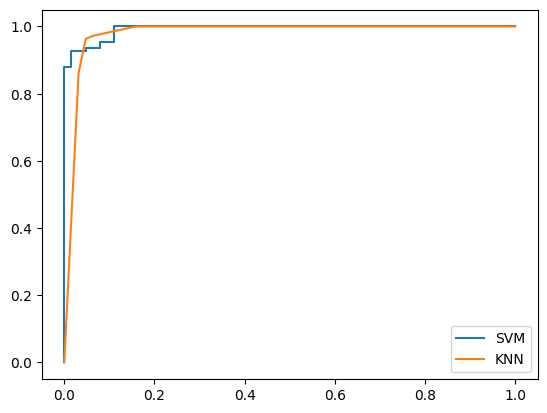

In [33]:
#1.d
print("SVM Accuracy:", accuracy_score(y_test, y_pred_s))
print("KNN Accuracy:", np.mean(y_pred_k == y_test))

y_prob_svm = svm.predict_proba(X_test)[:,1]

def knn_prob(X_train, y_train, X_test, k=5):
  prob = []
  for test_point in X_test:
    distance = []
    for i in range(len(X_train)):
      dist = eculidDist(test_point, X_train[i])
      distance.append((dist, y_train[i]))
    distance.sort(key = lambda x:x[0])
    k_neighbors = distance[:k]
    labels = [label for _, label in k_neighbors]
    prob.append(sum(labels)/k)
  return np.array(prob)

y_prob_knn = knn_prob(X_train, y_train, X_test, k=5)

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)

plt.plot(fpr_svm, tpr_svm, label='SVM')
plt.plot(fpr_knn, tpr_knn, label='KNN')

plt.legend()
plt.show()